# Quality Indicators with Estimated Reference Fronts (RE22)

This notebook generates a figure illustrating how the EP (additive Epsilon, ε⁺) and HV (Hypervolume) quality indicators behave when using estimated reference fronts.

The estimated reference front is generated from the true reference front by extracting extreme points and applying a 30% range-based offset.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add jMetalPy source to path
sys.path.insert(0, '/Users/ajnebro/Softw/jMetal/jMetalPy/src')
from jmetal.core.quality_indicator import AdditiveEpsilonIndicator, HyperVolume

plt.rcParams.update({
    'font.size': 11, 'font.family': 'serif',
    'axes.labelsize': 13, 'axes.titlesize': 14,
    'legend.fontsize': 9.5, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
%matplotlib inline

In [2]:
# Load data
rf = np.loadtxt('../../../resources/referenceFronts/RE22.csv', delimiter=',')
erf = np.loadtxt('../../../resources/estimatedReferenceFronts/RE22.csv', delimiter=',')

ref_point = np.max(erf, axis=0).tolist()
print(f"Reference front: {rf.shape[0]} points")
print(f"Estimated reference front:\n{erf}")
print(f"Reference point for HV: ({ref_point[0]:.2f}, {ref_point[1]:.2f})")

Reference front: 1000 points
Estimated reference front:
[[467.8778285  54.004641 ]
 [112.4948835 234.020111 ]]
Reference point for HV: (467.88, 234.02)


## Generate Synthetic Fronts

- **Front A**: Scaled and translated (centroid at (600, 350)), dominated by the reference point → HV = 0
- **Front B**: Scaled by 1.30, partially extends beyond the reference point region, EP < 0
- **Front C**: Scaled by 1.15, dominates Front B, EP < 0, EP(C) < EP(B)

In [3]:
# Sample 20 evenly-spaced points from the sorted reference front
sorted_rf = rf[np.argsort(rf[:, 0])]
indices = np.linspace(0, len(sorted_rf) - 1, 20, dtype=int)
base_points = sorted_rf[indices]

# Front A: Dominated by the reference point, HV = 0
# Scale and translate so centroid is at (600, 350) and all points >= ref_point
centroid = base_points.mean(axis=0)
target_centroid = np.array([600.0, 350.0])
s_obj1 = (target_centroid[0] - ref_point[0]) / (centroid[0] - base_points[:, 0].min())
s_obj2 = (target_centroid[1] - ref_point[1]) / (centroid[1] - base_points[:, 1].min())
scale_a = min(s_obj1, s_obj2) * 0.95
front_a = target_centroid + scale_a * (base_points - centroid)

# Front B: Partially dominated by the reference point, EP < 0
front_b = base_points * 1.30

# Front C: Dominates Front B, EP < 0, EP_C < EP_B
front_c = base_points * 1.15

In [4]:
# Compute quality indicators
hv_indicator = HyperVolume(reference_point=ref_point)
ep_indicator = AdditiveEpsilonIndicator(reference_front=erf)

hv_a = hv_indicator.compute(front_a)
hv_b = hv_indicator.compute(front_b)
hv_c = hv_indicator.compute(front_c)

ep_a = ep_indicator.compute(front_a)
ep_b = ep_indicator.compute(front_b)
ep_c = ep_indicator.compute(front_c)

print("Quality Indicators:")
print(f"  Front A — HV: {hv_a:>10.2f}  EP: {ep_a:>8.2f}")
print(f"  Front B — HV: {hv_b:>10.2f}  EP: {ep_b:>8.2f}")
print(f"  Front C — HV: {hv_c:>10.2f}  EP: {ep_c:>8.2f}")

print(f"\nConstraint checks:")
print(f"  HV(A) == 0: {hv_a == 0.0}")
print(f"  EP(B) < 0:  {ep_b < 0}")
print(f"  EP(C) < 0:  {ep_c < 0}")
print(f"  EP(C) < EP(B): {ep_c < ep_b}")

Quality Indicators:
  Front A — HV:       0.00  EP:   361.99
  Front B — HV:   56823.46  EP:   -17.50
  Front C — HV:   68089.94  EP:   -40.39

Constraint checks:
  HV(A) == 0: True
  EP(B) < 0:  True
  EP(C) < 0:  True
  EP(C) < EP(B): True


## Figure

Figure saved as approx_reference_front.pdf and .png


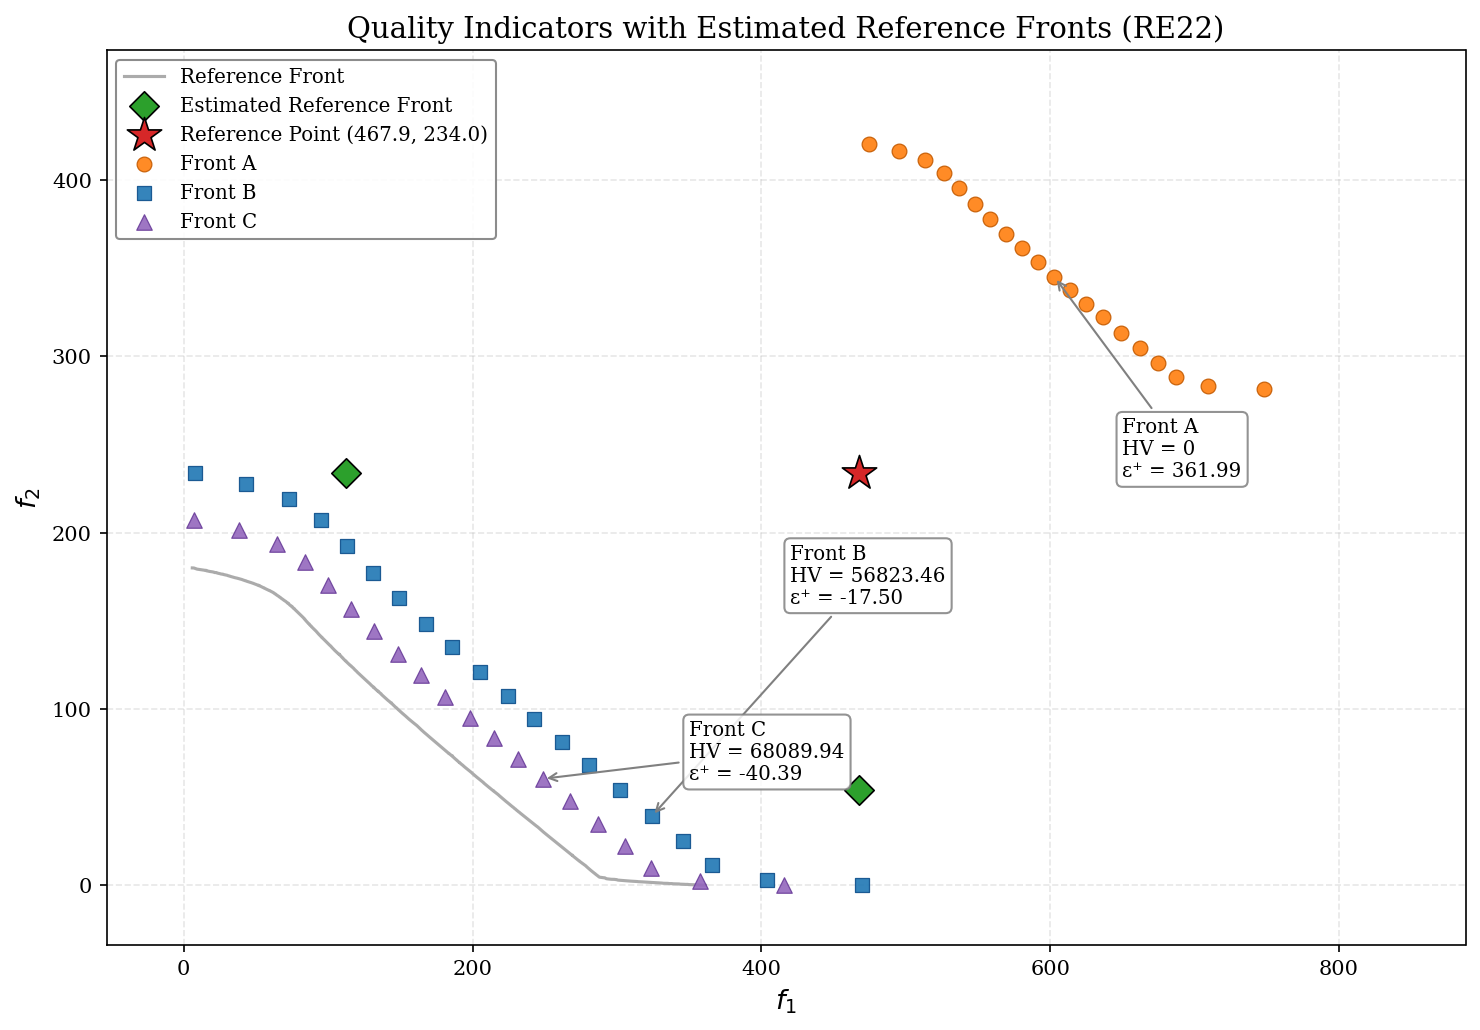

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

rf_sorted = rf[np.argsort(rf[:, 0])]
ax.plot(rf_sorted[:, 0], rf_sorted[:, 1], color="#888888", linewidth=1.5, alpha=0.7,
        label="Reference Front", zorder=1)
ax.scatter(erf[:, 0], erf[:, 1], marker="D", s=100, c="#2ca02c", edgecolors="black",
           linewidths=0.8, zorder=5, label="Estimated Reference Front")
ax.scatter(ref_point[0], ref_point[1], marker="*", s=300, c="#d62728", edgecolors="black",
           linewidths=0.8, zorder=6, label=f"Reference Point ({ref_point[0]:.1f}, {ref_point[1]:.1f})")
ax.scatter(front_a[:, 0], front_a[:, 1], marker="o", s=50, c="#ff7f0e", edgecolors="#c45a00",
           linewidths=0.6, alpha=0.9, zorder=4, label="Front A")
ax.scatter(front_b[:, 0], front_b[:, 1], marker="s", s=50, c="#1f77b4", edgecolors="#0d4f8b",
           linewidths=0.6, alpha=0.9, zorder=4, label="Front B")
ax.scatter(front_c[:, 0], front_c[:, 1], marker="^", s=55, c="#9467bd", edgecolors="#6a3d9a",
           linewidths=0.6, alpha=0.9, zorder=4, label="Front C")

# Annotations
ann = dict(fontsize=9.5, fontfamily="serif",
           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.85))
arr = dict(arrowstyle="->", color="gray", lw=1.0)

ax.annotate(f"Front A\nHV = {hv_a:.0f}\nε⁺ = {ep_a:.2f}",
    xy=(front_a[len(front_a)//2, 0], front_a[len(front_a)//2, 1]),
    xytext=(front_a[:, 0].mean() + 50, front_a[:, 1].min() - 50),
    arrowprops=arr, **ann, zorder=7)
ax.annotate(f"Front B\nHV = {hv_b:.2f}\nε⁺ = {ep_b:.2f}",
    xy=(front_b[len(front_b)*3//4, 0], front_b[len(front_b)*3//4, 1]),
    xytext=(420, 160), arrowprops=arr, **ann, zorder=7)
ax.annotate(f"Front C\nHV = {hv_c:.2f}\nε⁺ = {ep_c:.2f}",
    xy=(front_c[len(front_c)*2//3, 0], front_c[len(front_c)*2//3, 1]),
    xytext=(350, 60), arrowprops=arr, **ann, zorder=7)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")
ax.set_title("Quality Indicators with Estimated Reference Fronts (RE22)")
ax.legend(loc="upper left", framealpha=0.9, edgecolor="gray")
ax.grid(True, alpha=0.3, linestyle="--")

all_x = np.concatenate([rf[:, 0], erf[:, 0], [ref_point[0]], front_a[:, 0], front_b[:, 0], front_c[:, 0]])
all_y = np.concatenate([rf[:, 1], erf[:, 1], [ref_point[1]], front_a[:, 1], front_b[:, 1], front_c[:, 1]])
x_pad = (all_x.max() - all_x.min()) * 0.08
y_pad = (all_y.max() - all_y.min()) * 0.08
ax.set_xlim(all_x.min() - x_pad, all_x.max() + x_pad + 80)
ax.set_ylim(all_y.min() - y_pad, all_y.max() + y_pad + 20)

plt.tight_layout()
fig.savefig("approx_reference_front.pdf", format="pdf")
fig.savefig("approx_reference_front.png", format="png")
print("Figure saved as approx_reference_front.pdf and .png")
plt.show()